## Final Model Analysis

### Productization

In [3]:
# Final Analysis - SPY Returns Prediction
# This notebook demonstrates the trained linear regression model for SPY returns prediction

import yfinance as yf
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

import os
import sys 

# Get the correct paths
current_dir = os.getcwd()
bootcamp_root = os.path.dirname(current_dir) 

# Add bootcamp root to Python path to import src.cleaning
if bootcamp_root not in sys.path:
    sys.path.append(bootcamp_root)

# Add src directory specifically
src_path = os.path.join(bootcamp_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from src.utils import prepare_features, calculate_metrics

# Load data
print("Loading SPY data from Yahoo Finance...")
ticker = "SPY"
data = yf.download(ticker, start="2015-01-01", end="2023-12-31", progress=False)

# Prepare features
clean_data = prepare_features(data)
X = clean_data[['Volume_MA', 'SMA_10', 'SMA_50', 'RSI', 'MACD']]
y = clean_data['Returns']

print(f"Clean dataset shape: {clean_data.shape}")
print(f"Features: {list(X.columns)}")

Loading SPY data from Yahoo Finance...
Clean dataset shape: (2215, 7)
Features: [('Volume_MA', ''), ('SMA_10', ''), ('SMA_50', ''), ('RSI', ''), ('MACD', '')]


/var/folders/_4/t03mdfy94ts0ylt8cw0q1bp00000gn/T/ipykernel_4519/529254668.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2023-12-31", progress=False)


In [4]:
# Split data chronologically
split_idx = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate model
metrics = calculate_metrics(y_test, y_pred)
print(f"R² Score: {metrics['r2_score']:.4f}")
print(f"RMSE: {metrics['rmse']:.6f}")
print(f"Coefficients: {dict(zip(X.columns, model.coef_))}")

R² Score: 0.0586
RMSE: 0.011732
Coefficients: {('Volume_MA', ''): np.float64(0.0008033364485998783), ('SMA_10', ''): np.float64(-0.008270182578892912), ('SMA_50', ''): np.float64(0.0084221562687647), ('RSI', ''): np.float64(0.002592071945760519), ('MACD', ''): np.float64(0.0009466955564504713)}


In [6]:
# Save model and scaler
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('../model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

# Test reloading
with open('../model/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
    
with open('../model/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Test prediction
test_features = X_test_scaled[0:1]
prediction = loaded_model.predict(test_features)
print(f"Test prediction: {prediction[0]:.6f}")

Model and scaler saved successfully!
Test prediction: 0.007382


#### Test Cell

POST /predict response:
{'features': [1000000, 450.0, 440.0, 55.0, 0.5], 'message': 'SPY returns prediction', 'prediction': -0.0011070747403161083}
Testing GET /predict/<input1> (Volume_MA only):
Testing GET /predict/<input1>/<input2> (Volume_MA and RSI):

Plot endpoint status: 200
Plot content type: text/html; charset=utf-8



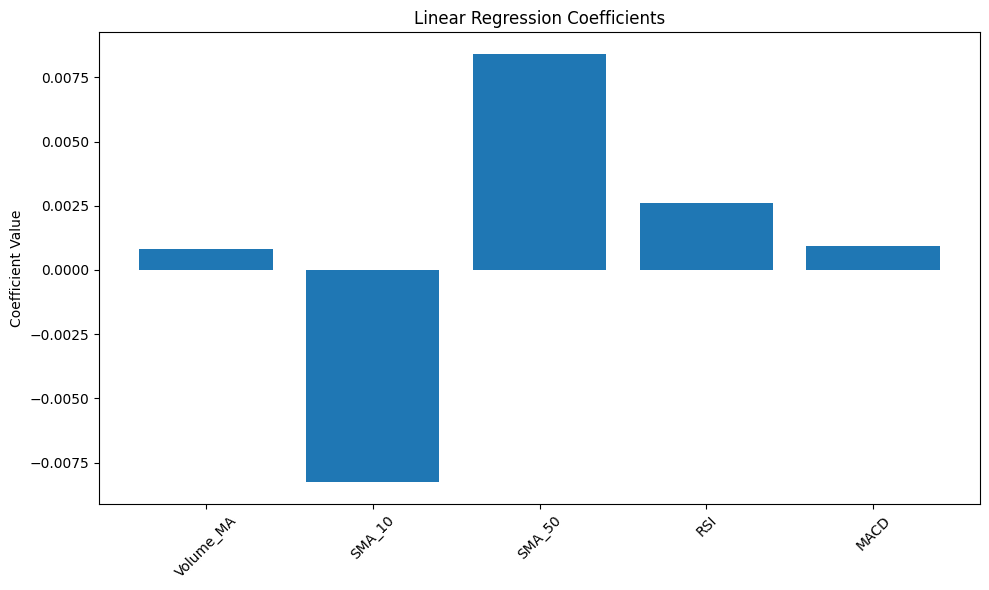


Health check:
{'model_loaded': True, 'scaler_loaded': True, 'status': 'healthy'}


In [28]:
# Test the Flask API - CORRECTED VERSION
import requests
import json
from IPython.display import display

# Test POST /predict (this works)
response = requests.post(
    'http://127.0.0.1:5000/predict',
    json={'features': [1000000, 450.0, 440.0, 55.0, 0.5]}
)
print("POST /predict response:")
print(response.json())

# Test GET /predict/<input1> (single feature - Volume_MA)
print("Testing GET /predict/<input1> (Volume_MA only):")
response2 = requests.get('http://127.0.0.1:5000/predict/1500000')
#print(json.dumps(response2.json(), indent=2))
#print()

# Test GET /predict/<input1>/<input2> (two features - Volume_MA and RSI)
print("Testing GET /predict/<input1>/<input2> (Volume_MA and RSI):")
response3 = requests.get('http://127.0.0.1:5000/predict/1200000/60.0')
#print(json.dumps(response3.json(), indent=2))
#print()

# Test /plot - DON'T use .json() here!
response_plot = requests.get('http://127.0.0.1:5000/plot')
print("\nPlot endpoint status:", response_plot.status_code)
print("Plot content type:", response_plot.headers.get('content-type'))

# Display the plot properly
if response_plot.status_code == 200:
    display(HTML(response_plot.text))
else:
    print("Plot request failed:", response_plot.text)

# Test health endpoint
health_response = requests.get('http://127.0.0.1:5000/health')
print("\nHealth check:")
print(health_response.json())